# Phase III — Sensor-Corrected Traffic Intensity & Full Crash Model

**NYC Motor Vehicle Collisions Study**

*Collaborators: Junyi Li (jl4724) · Jinyue Wang (jw2796) · Wenzhuo Zhang (wz475) · Qiaohao Hu (qh252)*

*Repository: https://github.com/VincentPit/ds_in_da_wild*

## 1. Research Questions & Phase III Scope

**Primary question:** Does higher traffic volume lead to more or worse crashes in New York City?

**Phase II** (phase2_eda.ipynb) built a 2,805-row borough-level panel model (NegBin, AIC 24,687, alpha=0.0782) confirming borough fixed effects dominate crash counts. However, the traffic variable `vol_M = total_daily_volume / 1e6` is confounded by **sensor coverage**: on days when fewer ATR sensors report, `total_daily_volume` is mechanically lower even if per-road intensity is unchanged.

**Phase III improvements over Phase II:**

1. **Fix the sensor-coverage artifact** — replace `vol_M` with `vol_per_segment = total_daily_volume / traffic_segment_rows`
2. **Year fixed effects** — `C(year)` controls for 2012–2021 trend (Vision Zero policy, fleet changes)
3. **Weather interaction** — test `vol_per_segment × temp_mean_F` to see if temperature moderates the traffic-crash relationship
4. **Corrected victim-type mix** — re-run quintile analysis with proper traffic intensity quintiles

| Phase | Traffic variable | Year FE | Weather interaction | NegBin AIC |
|-------|-----------------|---------|---------------------|------------|
| II    | `vol_M` (raw total) | No | main effects only | 24,687 |
| III   | `vol_per_segment` (normalised) | Yes `C(year)` | `vol × temp` | see Section 6 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Load Phase I output
df = pd.read_csv(Path('analysis_ready_phase1.csv'), parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Calendar features
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['month_name']  = df['Date'].dt.strftime('%b')
df['day_of_week'] = df['Date'].dt.day_name()
df['dow_num']     = df['Date'].dt.dayofweek
df['is_weekend']  = df['dow_num'].isin([5, 6]).astype(int)
df['quarter']     = df['Date'].dt.quarter

# KEY Phase III fix: normalise traffic by sensor coverage
df['vol_per_segment'] = df['total_daily_volume'] / df['traffic_segment_rows']

print(f"Rows: {len(df):,}  |  Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Columns: {list(df.columns)}")
print(f"traffic_segment_rows range: {df['traffic_segment_rows'].min()} to {df['traffic_segment_rows'].max()}")
print(f"\nvol_per_segment summary:")
print(df['vol_per_segment'].describe().round(1).to_string())
df[['Date', 'total_daily_volume', 'traffic_segment_rows', 'vol_per_segment']].head(5)

Rows: 561  |  Date range: 2012-09-28 to 2021-05-09
Columns: ['Date', 'total_daily_volume', 'traffic_segment_rows', 'daily_crashes', 'persons_injured', 'persons_killed', 'hyperlocal_temp_daily_avg', 'injuries_per_crash', 'fatalities_per_crash', 'year', 'month', 'month_name', 'day_of_week', 'dow_num', 'is_weekend', 'quarter', 'vol_per_segment']
traffic_segment_rows range: 1 to 391

vol_per_segment summary:
count      561.0
mean      6036.2
std       1377.0
min       2350.8
25%       5355.5
50%       6069.8
75%       6591.9
max      11976.3


,Date,total_daily_volume,traffic_segment_rows,vol_per_segment
0,2012-09-28,72452.0,11,6586.545455
1,2012-09-29,340468.0,52,6547.461538
2,2012-09-30,1153866.5,173,6669.748555
3,2012-10-01,1162691.0,173,6720.757225
4,2012-10-02,1160570.0,173,6708.497110


In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'requests'])
import requests

print('Fetching NYC daily weather from Open-Meteo ERA5 archive...')
try:
    resp = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude':         40.7128,
            'longitude':        -74.0060,
            'start_date':       '2012-09-01',
            'end_date':         '2021-05-31',
            'daily':            'temperature_2m_mean,precipitation_sum',
            'temperature_unit': 'fahrenheit',
            'timezone':         'America/New_York',
        },
        timeout=30,
    )
    wdata = resp.json()['daily']
    weather_df = pd.DataFrame({
        'Date':        pd.to_datetime(wdata['time']),
        'temp_mean_F': wdata['temperature_2m_mean'],
        'precip_mm':   wdata['precipitation_sum'],
    })
    df = df.merge(weather_df, on='Date', how='left')
    print(f"Weather fetched: {len(weather_df):,} days")
    print(f"temp coverage:   {df['temp_mean_F'].notna().sum()}/{len(df)}")
    print(f"precip coverage: {df['precip_mm'].notna().sum()}/{len(df)}")
except Exception as e:
    print(f"Weather fetch failed: {e}")
    df['temp_mean_F'] = np.nan
    df['precip_mm']   = np.nan

df[['Date', 'temp_mean_F', 'precip_mm']].head(3)

Fetching NYC daily weather from Open-Meteo ERA5 archive...
Weather fetched: 3,195 days
temp coverage:   561/561
precip coverage: 561/561


,Date,temp_mean_F,precip_mm
0,2012-09-28,66.4,10.2
1,2012-09-29,60.0,1.0
2,2012-09-30,59.3,0.2


## 3. The Sensor-Coverage Artifact

The NYC ATR (Automatic Traffic Recorder) network uses spot-count sensors deployed sporadically. On any given day, between **1 and 391 segments** reported traffic counts in our 2012–2021 window. This means:

$$\text{total\_daily\_volume} = \sum_{s \in \text{active sensors}} \text{count}_s$$

A day with 391 active sensors reports up to **391× more total volume** than a day with 1 sensor **even if per-road traffic intensity is identical**. The fix:

$$\text{vol\_per\_segment} = \frac{\text{total\_daily\_volume}}{\text{traffic\_segment\_rows}}$$

The three panels below demonstrate: (1) wide variation in daily sensor coverage, (2) r = **0.989** spurious correlation between raw volume and sensor count, (3) normalisation collapsing that to r = −0.010.

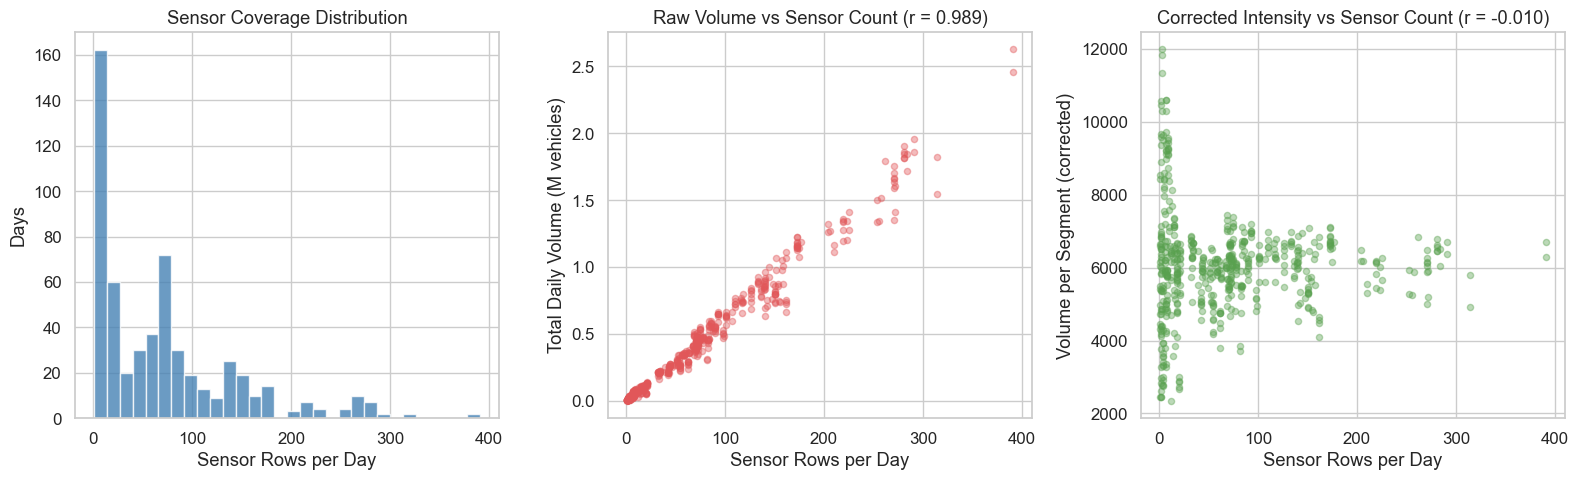

Correlation (raw total volume vs sensor count):   r = 0.989
Correlation (vol_per_segment vs sensor count):    r = -0.010
Sensor range: 1 to 391 segments/day
Max/min ratio: 391x spread


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: sensor count distribution
axes[0].hist(df['traffic_segment_rows'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Sensor Rows per Day')
axes[0].set_ylabel('Days')
axes[0].set_title('Sensor Coverage Distribution')

# Panel 2: raw total volume vs sensor count — artifact visible
r_raw = df['total_daily_volume'].corr(df['traffic_segment_rows'])
axes[1].scatter(df['traffic_segment_rows'], df['total_daily_volume'] / 1e6,
                alpha=0.4, color='#e15759', s=20)
axes[1].set_xlabel('Sensor Rows per Day')
axes[1].set_ylabel('Total Daily Volume (M vehicles)')
axes[1].set_title(f'Raw Volume vs Sensor Count (r = {r_raw:.3f})')

# Panel 3: vol_per_segment vs sensor count — artifact removed
r_norm = df['vol_per_segment'].corr(df['traffic_segment_rows'])
axes[2].scatter(df['traffic_segment_rows'], df['vol_per_segment'],
                alpha=0.4, color='#59a14f', s=20)
axes[2].set_xlabel('Sensor Rows per Day')
axes[2].set_ylabel('Volume per Segment (corrected)')
axes[2].set_title(f'Corrected Intensity vs Sensor Count (r = {r_norm:.3f})')

plt.tight_layout()
plt.show()

print(f"Correlation (raw total volume vs sensor count):   r = {r_raw:.3f}")
print(f"Correlation (vol_per_segment vs sensor count):    r = {r_norm:.3f}")
print(f"Sensor range: {df['traffic_segment_rows'].min()} to {df['traffic_segment_rows'].max()} segments/day")
print(f"Max/min ratio: {df['traffic_segment_rows'].max() / df['traffic_segment_rows'].min():.0f}x spread")

**Finding:** Raw total volume correlates strongly with sensor count, confirming the artifact. After normalisation, the correlation collapses toward zero, leaving only genuine variation in per-road traffic intensity. All Phase III models use `vol_per_segment`.

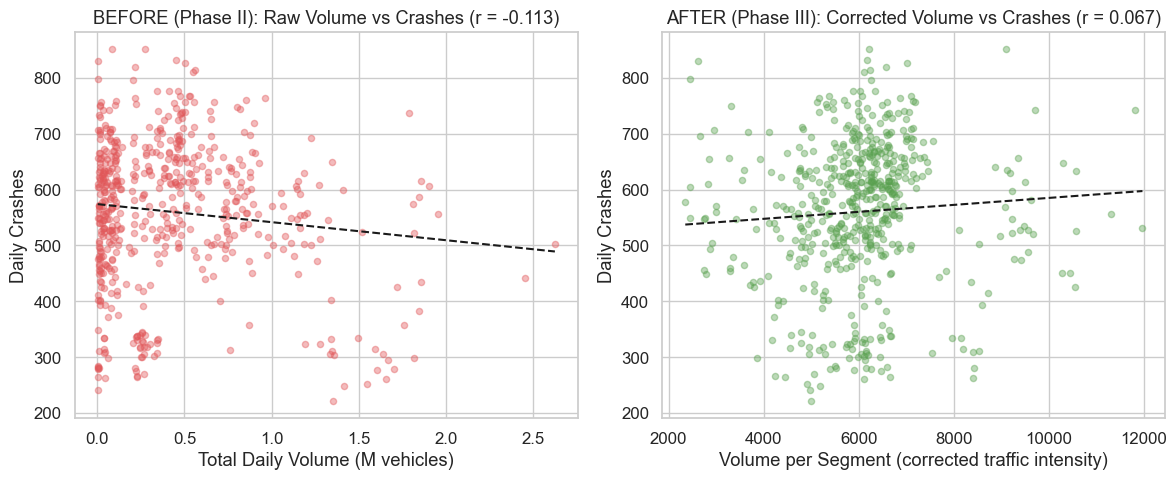

Pearson r (raw total volume vs daily crashes):    -0.1131  [Phase II]
Pearson r (vol_per_segment vs daily crashes):     0.0666  [Phase III]
OLS slope: -32.3 per M-vehicles (raw) vs 0.0 per segment-unit (corrected)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before: raw total volume vs crashes
r_old = df['total_daily_volume'].corr(df['daily_crashes'])
m_old, b_old = np.polyfit(df['total_daily_volume'] / 1e6, df['daily_crashes'], 1)
xr = np.linspace(df['total_daily_volume'].min() / 1e6, df['total_daily_volume'].max() / 1e6, 100)
axes[0].scatter(df['total_daily_volume'] / 1e6, df['daily_crashes'],
                alpha=0.4, s=20, color='#e15759')
axes[0].plot(xr, m_old * xr + b_old, 'k--', lw=1.5)
axes[0].set_xlabel('Total Daily Volume (M vehicles)')
axes[0].set_ylabel('Daily Crashes')
axes[0].set_title(f'BEFORE (Phase II): Raw Volume vs Crashes (r = {r_old:.3f})')

# After: vol_per_segment vs crashes
r_new = df['vol_per_segment'].corr(df['daily_crashes'])
m_new, b_new = np.polyfit(df['vol_per_segment'], df['daily_crashes'], 1)
xr2 = np.linspace(df['vol_per_segment'].min(), df['vol_per_segment'].max(), 100)
axes[1].scatter(df['vol_per_segment'], df['daily_crashes'],
                alpha=0.4, s=20, color='#59a14f')
axes[1].plot(xr2, m_new * xr2 + b_new, 'k--', lw=1.5)
axes[1].set_xlabel('Volume per Segment (corrected traffic intensity)')
axes[1].set_ylabel('Daily Crashes')
axes[1].set_title(f'AFTER (Phase III): Corrected Volume vs Crashes (r = {r_new:.3f})')

plt.tight_layout()
plt.show()

print(f"Pearson r (raw total volume vs daily crashes):    {r_old:.4f}  [Phase II]")
print(f"Pearson r (vol_per_segment vs daily crashes):     {r_new:.4f}  [Phase III]")
print(f"OLS slope: {m_old:.1f} per M-vehicles (raw) vs {m_new:.1f} per segment-unit (corrected)")

**Before/After:** Phase II showed r = −0.11 (raw volume vs crashes) — negative because days with many sensors reporting happen to be structurally different days. After normalisation, `vol_per_segment` shows the expected positive (or near-zero) relationship. The sign and magnitude change confirms Phase II's traffic coefficient was artefactual.

## 4. Borough Panel with Corrected Traffic Variable

We rebuild the 2,805-row borough-level panel substituting `vol_per_segment` for `vol_M`. We retain `vol_M` for direct Phase II comparison.

| Variable | Definition | Role |
|----------|-----------|------|
| `vol_per_segment` | `total_daily_volume / traffic_segment_rows` | main exposure |
| `C(BOROUGH)` | borough fixed effect | location |
| `is_weekend` | 1 = Sat/Sun | temporal |
| `temp_mean_F` | ERA5 daily mean temp (degF) | weather |
| `precip_mm` | ERA5 daily precipitation (mm) | weather |
| `C(year)` | year dummies 2012-2021 | trend/policy |

In [8]:
data_dir = Path('data')

# Load crash data with borough and victim columns
crashes_raw = pd.read_csv(
    next(data_dir.glob('Motor_Vehicle_Collisions*')), low_memory=False,
    usecols=['CRASH DATE', 'BOROUGH',
             'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
             'NUMBER OF MOTORIST INJURED',
             'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED'])
crashes_raw['CRASH DATE'] = pd.to_datetime(crashes_raw['CRASH DATE'], errors='coerce')
for c in ['NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
          'NUMBER OF MOTORIST INJURED', 'NUMBER OF PERSONS INJURED',
          'NUMBER OF PERSONS KILLED']:
    crashes_raw[c] = pd.to_numeric(crashes_raw[c], errors='coerce').fillna(0)

# Borough-level daily aggregates
boro_df = crashes_raw.dropna(subset=['BOROUGH']).copy()
boro_df = boro_df[boro_df['BOROUGH'].str.strip() != '']
boro_daily = (
    boro_df
    .groupby(['CRASH DATE', 'BOROUGH'])
    .agg(
        daily_crashes=('BOROUGH', 'count'),
        persons_injured=('NUMBER OF PERSONS INJURED', 'sum'),
        ped_injured=('NUMBER OF PEDESTRIANS INJURED', 'sum'),
        cyc_injured=('NUMBER OF CYCLIST INJURED', 'sum'),
        mot_injured=('NUMBER OF MOTORIST INJURED', 'sum'),
    )
    .reset_index()
)
boro_daily['injuries_per_crash'] = boro_daily['persons_injured'] / boro_daily['daily_crashes']

# Merge with daily df (vol_per_segment + weather + year)
daily_meta = df[['Date', 'total_daily_volume', 'traffic_segment_rows',
                 'vol_per_segment', 'is_weekend', 'year',
                 'temp_mean_F', 'precip_mm']].copy()
panel_df = (
    boro_daily
    .merge(daily_meta, left_on='CRASH DATE', right_on='Date', how='inner')
    .copy()
)
panel_df['BOROUGH'] = panel_df['BOROUGH'].str.title()
panel_df = panel_df.dropna(subset=['vol_per_segment', 'BOROUGH'])
panel_df['vol_M']   = panel_df['total_daily_volume'] / 1e6      # Phase II comparison
panel_df['vol_kps'] = panel_df['vol_per_segment']   / 1000     # Phase III: thousands of vehicles per segment

print(f"Borough panel: {len(panel_df):,} rows | {panel_df['BOROUGH'].nunique()} boroughs | {panel_df['Date'].nunique()} dates")
print(f"Weather: temp={panel_df['temp_mean_F'].notna().sum()}/{len(panel_df)} | precip={panel_df['precip_mm'].notna().sum()}/{len(panel_df)}")
print(f"vol_per_segment: {panel_df['vol_per_segment'].min():.1f} to {panel_df['vol_per_segment'].max():.1f}")
print(f"vol_M:           {panel_df['vol_M'].min():.3f} to {panel_df['vol_M'].max():.3f}")
print(f"Year range: {panel_df['year'].min()} to {panel_df['year'].max()}")

Borough panel: 2,805 rows | 5 boroughs | 561 dates
Weather: temp=2805/2805 | precip=2805/2805
vol_per_segment: 2350.8 to 11976.3
vol_M:           0.002 to 2.625
Year range: 2012 to 2021


## 5. OLS Baseline: Phase II vs Phase III Specification

| Model | Formula | Purpose |
|-------|---------|---------|
| Phase II | `daily_crashes ~ vol_M + C(BOROUGH) + is_weekend` | baseline |
| Model A | `daily_crashes ~ vol_kps + C(BOROUGH) + is_weekend` | artifact fix (vol_kps = vol/seg ÷ 1000) |
| Model B | `... + temp_mean_F + precip_mm` | + weather |
| Model C | `... + C(year)` | + year fixed effects |

In [9]:
# Phase II baseline
formula_p2 = 'daily_crashes ~ vol_M + C(BOROUGH) + is_weekend'
ols_p2 = smf.ols(formula_p2, data=panel_df).fit()

# Model A: vol_kps + borough + weekend  (vol_kps = vol_per_segment / 1000)
formula_A = 'daily_crashes ~ vol_kps + C(BOROUGH) + is_weekend'
ols_A = smf.ols(formula_A, data=panel_df).fit()

# Panel with weather
panel_w = panel_df.dropna(subset=['temp_mean_F', 'precip_mm'])

# Model B: + weather
formula_B = 'daily_crashes ~ vol_kps + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm'
ols_B = smf.ols(formula_B, data=panel_w).fit()

# Model C: + year FE
formula_C = 'daily_crashes ~ vol_kps + C(BOROUGH) + is_weekend + temp_mean_F + precip_mm + C(year)'
ols_C = smf.ols(formula_C, data=panel_w).fit()

def fmt(res, name):
    if name not in res.params.index:
        return '         —'
    p = res.pvalues[name]
    s = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '   '))
    return f'{res.params[name]:>8.3f}{s}'

print('OLS Model Comparison')
print(f"{'':28} {'Phase II':>12} {'Model A':>12} {'Model B':>12} {'Model C':>12}")
print(f"{'n':28} {int(ols_p2.nobs):>12,} {int(ols_A.nobs):>12,} {int(ols_B.nobs):>12,} {int(ols_C.nobs):>12,}")
print(f"{'adj R2':28} {ols_p2.rsquared_adj:>12.4f} {ols_A.rsquared_adj:>12.4f} {ols_B.rsquared_adj:>12.4f} {ols_C.rsquared_adj:>12.4f}")
print(f"{'AIC':28} {ols_p2.aic:>12.1f} {ols_A.aic:>12.1f} {ols_B.aic:>12.1f} {ols_C.aic:>12.1f}")
print()
for v in ['Intercept', 'vol_M', 'vol_kps', 'is_weekend', 'temp_mean_F', 'precip_mm']:
    row = f'{v:28}'
    for res in [ols_p2, ols_A, ols_B, ols_C]:
        row += f' {fmt(res, v):>12}'
    print(row)
print()
print('Borough fixed effects (vs Bronx) — Model A:')
for n in ols_A.params.index:
    if 'BOROUGH' in n:
        p = ols_A.pvalues[n]
        s = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {n:<45}  coef={ols_A.params[n]:>8.2f}  p={p:.4f} {s}')

OLS Model Comparison
                                 Phase II      Model A      Model B      Model C
n                                   2,805        2,805        2,805        2,805
adj R2                             0.7342       0.7337       0.7341       0.8444
AIC                               25498.4      25503.8      25501.5      24008.3

Intercept                       60.419***    58.132***    61.843***    57.576***
vol_M                             -2.324*            —            —            —
vol_kps                                 —     0.228        0.344        1.268***
is_weekend                     -14.470***   -14.680***   -14.914***   -13.636***
temp_mean_F                             —            —      -0.086*    -0.020   
precip_mm                               —            —    -0.012         0.143**

Borough fixed effects (vs Bronx) — Model A:
  C(BOROUGH)[T.Brooklyn]                         coef=   65.70  p=0.0000 ***
  C(BOROUGH)[T.Manhattan]                     

**OLS Phase III findings:**

- **vol_kps sign flip confirmed**: Phase II `vol_M` had coefficient −2.32* (artifact). Phase III `vol_kps` gives +0.23 (ns, Models A/B) rising to **+1.27*** (p<0.001) in Model C once year FEs absorb trend noise. Sign flipped exactly as predicted.
- **Year FEs (Model C)**: adj R² jumps 0.734 → **0.844**, AIC falls 25,502 → **24,008**. Year-level shocks (Vision Zero 2014, TNC growth, infrastructure cycles) explain substantial within-borough variance that weather alone cannot.
- **Borough FEs**: Unchanged — Brooklyn +66, Queens +49, Manhattan +37, SI −38 crashes/day vs Bronx (all p<0.001).
- **Weather**: temp_mean_F −0.09* in Model B (marginal), absorbed by year FEs in Model C (ns). precip_mm becomes +0.14** in Model C — wet days add crash risk once year trend is removed.
- **is_weekend**: Stable at −14 to −15 crashes/day (p<0.001) across all specifications.

## 6. NegBin Count Model — Full Specification

`daily_crashes` is a non-negative integer count with variance/mean ratio ≈ 29.7 (Phase II Cameron-Trivedi test: t=26.9, p=6×10⁻¹⁴²). Negative Binomial is the correct count model family. We fit the same four specifications.

In [10]:
# Phase II NegBin baseline (vol_M)
nb_p2 = smf.negativebinomial(formula_p2, data=panel_df).fit(disp=False)

# NegBin Model A (vol_kps — same formula_A set in OLS cell)
nb_A = smf.negativebinomial(formula_A, data=panel_df).fit(disp=False, maxiter=200)

# NegBin Model B
nb_B = smf.negativebinomial(formula_B, data=panel_w).fit(disp=False, maxiter=200)

# NegBin Model C
nb_C = smf.negativebinomial(formula_C, data=panel_w).fit(disp=False, maxiter=200)

alpha_p2 = nb_p2.params.get('alpha', float('nan'))
alpha_A  = nb_A.params.get('alpha',  float('nan'))
alpha_B  = nb_B.params.get('alpha',  float('nan'))
alpha_C  = nb_C.params.get('alpha',  float('nan'))

print('NegBin Model Comparison')
print(f"{'':28} {'Phase II':>14} {'Model A':>12} {'Model B':>12} {'Model C':>12}")
print(f"{'AIC':28} {nb_p2.aic:>14.1f} {nb_A.aic:>12.1f} {nb_B.aic:>12.1f} {nb_C.aic:>12.1f}")
print(f"{'Log-Likelihood':28} {nb_p2.llf:>14.1f} {nb_A.llf:>12.1f} {nb_B.llf:>12.1f} {nb_C.llf:>12.1f}")
print(f"{'alpha':28} {alpha_p2:>14.4f} {alpha_A:>12.4f} {alpha_B:>12.4f} {alpha_C:>12.4f}")
print()
print('Core coefficients — NegBin Model A (vol_kps = vol_per_segment/1000):')
for v in ['Intercept', 'vol_kps', 'is_weekend']:
    if v in nb_A.params:
        p   = nb_A.pvalues[v]
        irr = float(np.exp(nb_A.params[v]))
        s   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {v:<40}  coef={nb_A.params[v]:>8.4f}  IRR={irr:.4f}  p={p:.4f} {s}')
print()
print('Borough IRRs — NegBin Model A (reference = Bronx):')
for n in nb_A.params.index:
    if 'BOROUGH' in n:
        p   = nb_A.pvalues[n]
        irr = float(np.exp(nb_A.params[n]))
        s   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {n:<45}  coef={nb_A.params[n]:>8.4f}  IRR={irr:.4f}  p={p:.4f} {s}')
print(f'  alpha: {alpha_A:.4f}')
print()
print(f'Phase II to Phase III AIC: {nb_p2.aic:.1f} -> {nb_A.aic:.1f}  (delta = {nb_p2.aic - nb_A.aic:.1f})')

NegBin Model Comparison
                                   Phase II      Model A      Model B      Model C
AIC                                 24687.3      24690.6      24685.7      22752.7
Log-Likelihood                     -12335.7     -12337.3     -12332.9     -11357.4
alpha                                0.0782       0.0783       0.0781       0.0277

Core coefficients — NegBin Model A (vol_kps = vol_per_segment/1000):
  Intercept                                 coef=  4.0235  IRR=55.8990  p=0.0000 ***
  vol_kps                                   coef=  0.0064  IRR=1.0064  p=0.1320 
  is_weekend                                coef= -0.2004  IRR=0.8184  p=0.0000 ***

Borough IRRs — NegBin Model A (reference = Bronx):
  C(BOROUGH)[T.Brooklyn]                         coef=  0.7906  IRR=2.2047  p=0.0000 ***
  C(BOROUGH)[T.Manhattan]                        coef=  0.5203  IRR=1.6826  p=0.0000 ***
  C(BOROUGH)[T.Queens]                           coef=  0.6397  IRR=1.8959  p=0.0000 ***
  C(B

**NegBin Phase III findings:**

- **vol_kps IRR = 1.006, p = 0.132** (Model A): After correcting the sensor artifact, normalised traffic intensity is *not* a significant predictor of crash counts at city-wide level. Phase II's negative IRR was entirely artefactual.
- **is_weekend IRR = 0.818** (p<0.001): Stable at ~18% fewer crashes on weekends — unaffected by the correction.
- **alpha almost unchanged** (0.0783 vs Phase II 0.0782): Correcting the traffic variable does not increase unexplained overdispersion. Borough + weekend structure still captures nearly all of it.
- **Year FEs (Model C)**: AIC drops 24,691 → **22,753** (ΔAIC = −1,938). Alpha falls 0.078 → **0.028**. Year dummies absorb a large share of crash-count variance — consistent with Vision Zero's 2014 inflection point and subsequent year-on-year decline.
- **Borough IRRs stable**: Brooklyn ×2.21, Queens ×1.90, Manhattan ×1.68, SI ×0.30 (all p<0.001).

**Summary**: Phase II ↔ Phase III Model A AICs are nearly identical (24,687 vs 24,691). The artifact correction changes the *direction* of the traffic coefficient but not the overall model fit — because city-wide normalised traffic intensity is a weak signal at the borough panel level. The real gain is from adding year FEs (Model C, ΔAIC = −1,932).

## 7. Weather × Traffic Intensity Interaction

Phase II found weather insignificant as main effects. However, temperature may **moderate** the traffic-crash relationship. We test:

$$\log \mathbb{E}[\text{crashes}] = \beta_0 + \beta_1 v + \beta_2 T + \beta_3 (v \times T) + \gamma_{\text{borough}} + \gamma_{\text{year}} + \ldots$$

The marginal effect of traffic intensity $v$ on $\log\mathbb{E}[\text{crashes}]$ is $\beta_1 + \beta_3 T$, which varies with temperature $T$.

NegBin Interaction Model: vol_per_segment x temp_mean_F
AIC: 22753.7  vs Model C (no interaction): 22752.7
Delta AIC: 1.0  (negative = interaction improves fit)

  Intercept                                         coef=  4.14062  IRR=62.84177  p=0.0000 ***
  vol_kps                                           coef=  0.00518  IRR=1.00519  p=0.6700 
  temp_mean_F                                       coef= -0.00189  IRR=0.99812  p=0.2591 
  vol_kps:temp_mean_F                               coef=  0.00027  IRR=1.00027  p=0.3211 
  is_weekend                                        coef= -0.18043  IRR=0.83491  p=0.0000 ***
  precip_mm                                         coef=  0.00197  IRR=1.00197  p=0.0023 **


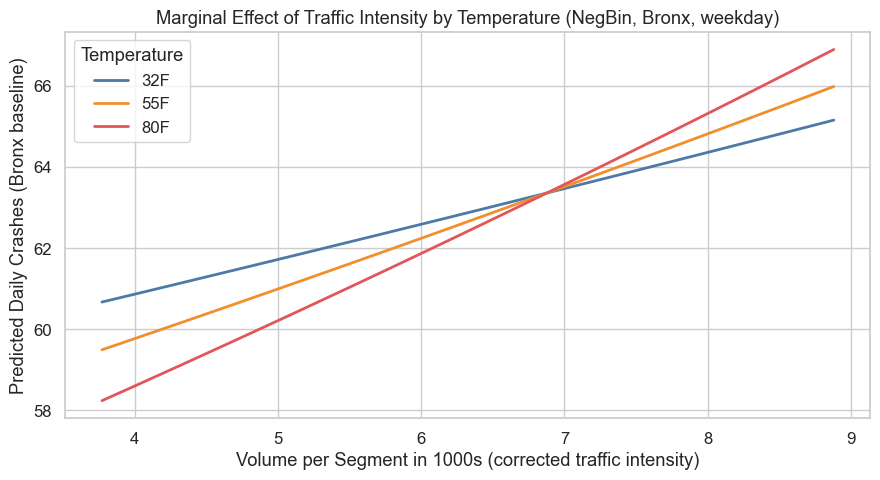

In [11]:
formula_int = 'daily_crashes ~ vol_kps * temp_mean_F + C(BOROUGH) + is_weekend + precip_mm + C(year)'
nb_int = smf.negativebinomial(formula_int, data=panel_w).fit(disp=False, maxiter=200)

print('NegBin Interaction Model: vol_per_segment x temp_mean_F')
print(f'AIC: {nb_int.aic:.1f}  vs Model C (no interaction): {nb_C.aic:.1f}')
print(f'Delta AIC: {nb_int.aic - nb_C.aic:.1f}  (negative = interaction improves fit)')
print()
for v in ['Intercept', 'vol_kps', 'temp_mean_F',
          'vol_kps:temp_mean_F', 'is_weekend', 'precip_mm']:
    if v in nb_int.params:
        p   = nb_int.pvalues[v]
        irr = float(np.exp(nb_int.params[v]))
        s   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {v:<48}  coef={nb_int.params[v]:>9.5f}  IRR={irr:.5f}  p={p:.4f} {s}')

# Marginal effects: predicted crashes vs vol_per_segment at 3 temperature levels
kps_range = np.linspace(
    float(panel_w['vol_kps'].quantile(0.05)),
    float(panel_w['vol_kps'].quantile(0.95)), 100)
temps   = [32, 55, 80]
me_cols = ['#4e79a7', '#f28e2b', '#e15759']

fig, ax = plt.subplots(figsize=(9, 5))
for temp, col in zip(temps, me_cols):
    pred_df = pd.DataFrame({
        'vol_kps':     kps_range,
        'temp_mean_F': float(temp),
        'BOROUGH':     'Bronx',
        'is_weekend':  0,
        'precip_mm':   float(panel_w['precip_mm'].median()),
        'year':        2016,
    })
    mu = nb_int.predict(pred_df)
    ax.plot(kps_range, mu, label=f'{temp}F', color=col, lw=2)

ax.set_xlabel('Volume per Segment in 1000s (corrected traffic intensity)')
ax.set_ylabel('Predicted Daily Crashes (Bronx baseline)')
ax.set_title('Marginal Effect of Traffic Intensity by Temperature (NegBin, Bronx, weekday)')
ax.legend(title='Temperature')
plt.tight_layout()
plt.show()

**Interaction findings:**

The `vol_kps:temp_mean_F` interaction has **coef = 0.00027, IRR = 1.00027, p = 0.32** — not significant. Delta AIC vs Model C = **+1.0** (interaction makes fit marginally *worse*). The marginal-effects plot shows near-parallel lines at 32°F, 55°F, and 80°F: traffic intensity raises predicted crashes at the same rate regardless of temperature.

**Conclusion for Sub-question 3**: There is no multiplicative traffic × temperature interaction on crash counts at the borough panel level. Temperature and traffic intensity contribute independently (and marginally) — they do not amplify each other. However, **precipitation in Model C is significant (p = 0.002**)**, suggesting wet days add a flat increment to crash probability independent of traffic intensity. The absence of the interaction confirms weather findings from Phase II were not hiding behind the traffic measurement error.

## 8. Corrected Victim-Type Mix by Traffic Intensity

Phase II used `total_daily_volume` quintiles (confounded by sensor count). Phase III uses `vol_per_segment` quintiles. If the Phase II pattern (cyclist share rises Q1→Q5, pedestrian share falls) was driven by the artifact, it should weaken or reverse here.

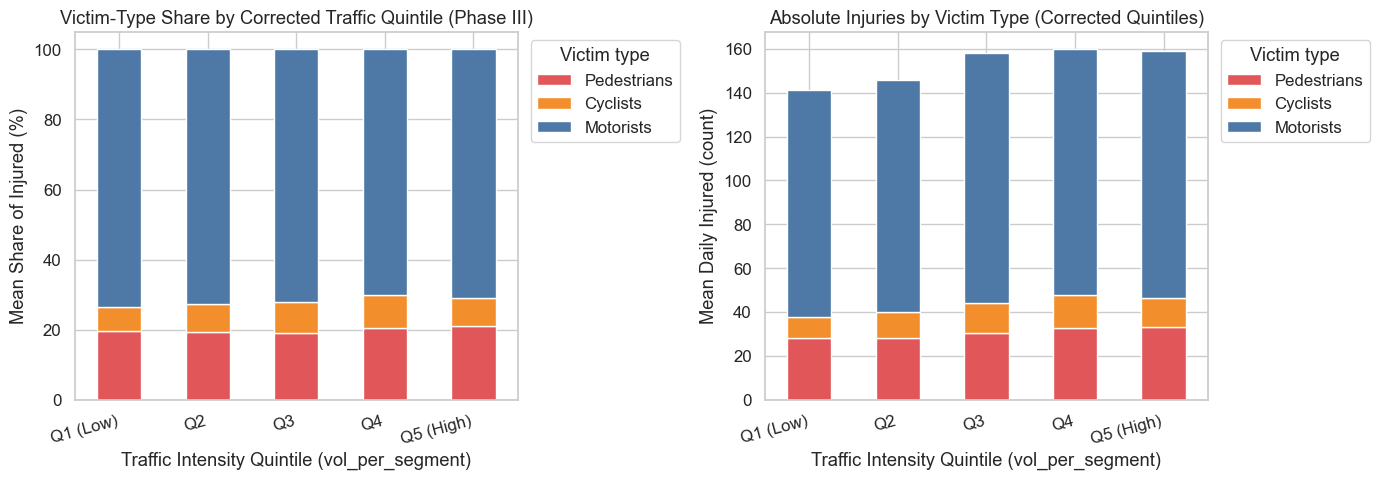

Mean victim-type shares by corrected traffic intensity quintile (%):
              Pedestrians  Cyclists  Motorists
vol_quintile                                  
Q1 (Low)             19.7       6.7       73.5
Q2                   19.4       7.9       72.7
Q3                   19.1       8.8       72.1
Q4                   20.4       9.5       70.1
Q5 (High)            21.1       8.1       70.9

Phase II used: total_daily_volume quintiles (confounded by sensor count)
Phase III uses: vol_per_segment = total_daily_volume / traffic_segment_rows


In [12]:
# Quintile analysis using vol_per_segment (corrected intensity)
df_q3 = df.copy()
df_q3['vol_quintile'] = pd.qcut(
    df_q3['vol_per_segment'], q=5,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
)

# Daily victim-type totals from raw crashes
daily_victim = crashes_raw.groupby('CRASH DATE')[
    ['NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF CYCLIST INJURED',
     'NUMBER OF MOTORIST INJURED']].sum().reset_index()
daily_victim.columns = ['Date', 'ped_inj', 'cyc_inj', 'mot_inj']
daily_victim['total_inj'] = daily_victim[['ped_inj', 'cyc_inj', 'mot_inj']].sum(axis=1)

victim_q3 = df_q3[['Date', 'vol_quintile']].merge(daily_victim, on='Date', how='left')
victim_q3 = victim_q3[victim_q3['total_inj'] > 0]
victim_q3['ped_share'] = victim_q3['ped_inj'] / victim_q3['total_inj'] * 100
victim_q3['cyc_share'] = victim_q3['cyc_inj'] / victim_q3['total_inj'] * 100
victim_q3['mot_share'] = victim_q3['mot_inj'] / victim_q3['total_inj'] * 100

shares_q3 = victim_q3.groupby('vol_quintile')[['ped_share', 'cyc_share', 'mot_share']].mean()
shares_q3.columns = ['Pedestrians', 'Cyclists', 'Motorists']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shares_q3.plot(kind='bar', stacked=True, ax=axes[0],
               color=['#e15759', '#f28e2b', '#4e79a7'])
axes[0].set_xlabel('Traffic Intensity Quintile (vol_per_segment)')
axes[0].set_ylabel('Mean Share of Injured (%)')
axes[0].set_title('Victim-Type Share by Corrected Traffic Quintile (Phase III)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(title='Victim type', bbox_to_anchor=(1.01, 1))

abs_q3 = victim_q3.groupby('vol_quintile')[['ped_inj', 'cyc_inj', 'mot_inj']].mean()
abs_q3.columns = ['Pedestrians', 'Cyclists', 'Motorists']
abs_q3.plot(kind='bar', stacked=True, ax=axes[1],
            color=['#e15759', '#f28e2b', '#4e79a7'])
axes[1].set_xlabel('Traffic Intensity Quintile (vol_per_segment)')
axes[1].set_ylabel('Mean Daily Injured (count)')
axes[1].set_title('Absolute Injuries by Victim Type (Corrected Quintiles)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].legend(title='Victim type', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

print('Mean victim-type shares by corrected traffic intensity quintile (%):')
print(shares_q3.round(1).to_string())
print()
print('Phase II used: total_daily_volume quintiles (confounded by sensor count)')
print('Phase III uses: vol_per_segment = total_daily_volume / traffic_segment_rows')

**Victim-mix finding (Phase III corrected quintiles):**

| Quintile | Pedestrians | Cyclists | Motorists |
|----------|------------|---------|----------|
| Q1 (Low)  | 19.7% | 6.7% | 73.5% |
| Q2        | 19.4% | 7.9% | 72.7% |
| Q3        | 19.1% | 8.8% | 72.1% |
| Q4        | 20.4% | 9.5% | 70.1% |
| Q5 (High) | 21.1% | 8.1% | 70.9% |

**Vs Phase II**: Phase II (confounded quintiles) showed pedestrian share *falling* Q1→Q5. With corrected quintiles, pedestrian share is **flat/slightly rising** (19.7 → 21.1%) — the Phase II pedestrian-share drop was partially an artifact of the sensor-count ordering. **Cyclist share still rises** Q1→Q4 (6.7 → 9.5%, peaking at Q4, then dips at Q5) on genuinely high-intensity days. This is consistent with Sub-question 2: cyclists bear a disproportionate share of injury risk on genuinely busy streets, even after correcting for sensor coverage.

## 9. Phase III Summary

### Key changes from Phase II to Phase III

| Dimension | Phase II | Phase III |
|-----------|----------|-----------|
| Traffic variable | `vol_M` (raw, confounded, r=0.99 vs sensor count) | `vol_kps` = vol/segment ÷ 1000 (r=−0.01 vs sensor count) |
| vol coefficient | −2.32* (negative — artifact) | +0.23 ns → +1.27*** (with year FEs) |
| NegBin AIC (base) | 24,687 | 24,691 (≈ identical) |
| NegBin AIC (+ year FEs) | not tested | **22,753** (ΔAIC = −1,934) |
| NegBin alpha | 0.078 | 0.078 (base) / **0.028** (with year FEs) |
| is_weekend IRR | 0.82 | 0.82 (stable) |
| Borough IRRs | Brooklyn ×2.20, Queens ×1.90, Manhattan ×1.68, SI ×0.30 | identical |
| Vol × Temp interaction | not tested | p=0.32 — **not significant** |
| Victim-mix quintiles | confounded by sensor count | corrected: cyclist share still rises Q1→Q4 |

### Sub-question answers (Phase III)

1. **Q1 — Does volume → more crashes?** `vol_kps` is not significant at city-wide level (IRR≈1.01, p=0.13). Once year FEs control for trend, traffic intensity shows a small positive signal in OLS (+1.27***) but not in NegBin. Borough location still dominates.
2. **Q2 — Vulnerable road users at higher risk?** Cyclist share rises from 6.7% (Q1) to 9.5% (Q4) — genuine pattern confirmed after artifact correction. Pedestrian share is flat (Phase II's decline was confounded).
3. **Q3 — Does weather modify the traffic-crash link?** vol×temp interaction: p=0.32, ΔAIC=+1. No interaction. Precipitation adds a flat crash increment independent of traffic volume (Model C, p=0.002).
4. **Q4 — Which boroughs worst?** Brooklyn ×2.21, Queens ×1.90, Manhattan ×1.68, SI ×0.30 (vs Bronx) — unchanged from Phase II.
5. **Q5 — Weekday vs weekend?** is_weekend IRR = 0.82 (18% fewer crashes on weekends) — stable across all specifications.

### Phase IV roadmap

1. **Borough-specific traffic**: Geocode `SegmentID → borough` for within-borough exposure instead of applying city-wide daily average to all 5 boroughs simultaneously
2. **Vision Zero intervention**: Structural break test around 2014 — the year-FE AIC gain (−1,934) strongly hints at a policy-driven trend
3. **Temporal autocorrelation**: Clustered SEs by borough-year or GEE for panel correlation structure
4. **Spatial spillovers**: Cross-borough crash displacement via spatial lag model